# Experimental CNN with Fractal (Sierpiński) Pooling
This notebook implements a compact PyTorch CNN using a custom Sierpiński-inspired pooling layer for academic benchmarking.

1 1.1013622336917452
2 1.0964212497075398
3 1.0923142433166504
4 1.0867664708031548
5 1.0779979467391967
6 1.078093613518609
7 1.0688214739163717
8 1.0570182972484166
9 1.069177602397071
10 1.0522192067570157
11 1.0507013161977132
12 1.0550843821631537
13 1.0397077679634095
14 1.0427511546346877
15 1.028484386867947
16 1.034307058652242
17 1.0498316446940104
18 1.0306397808922663
19 1.044356644153595
20 1.0407289955351087
Weighted F1: 0.45181956299425324
Done.


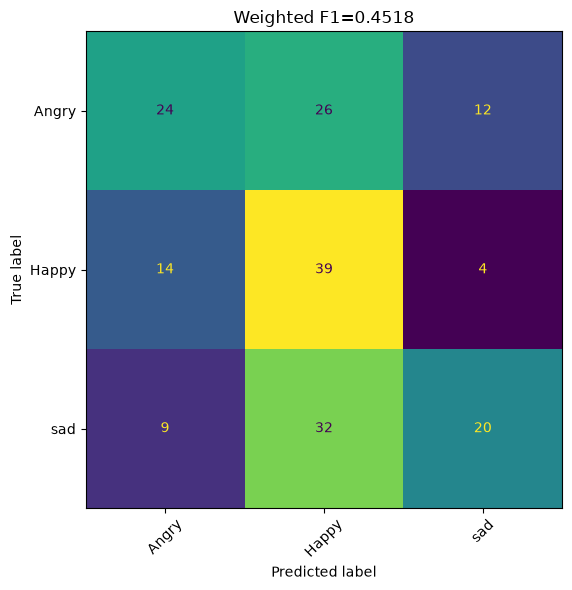

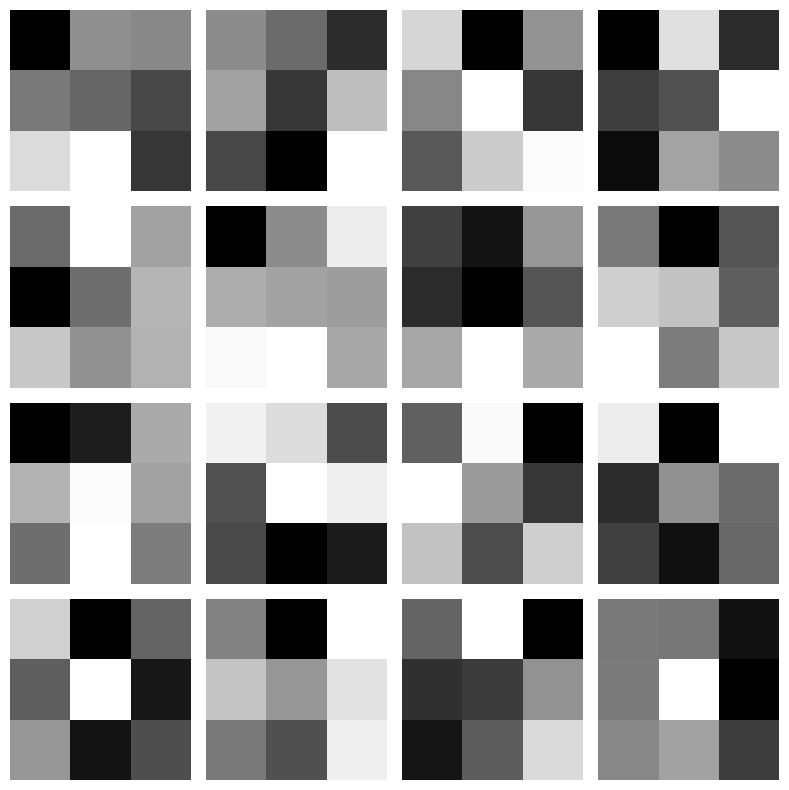

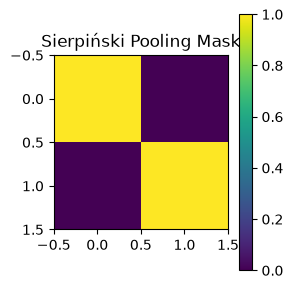

In [1]:

import os, zipfile, random
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

MAX_EPOCHS=50
PATIENCE=5
BATCH_SIZE=16
IMG_SIZE=224
DEVICE="cuda" if torch.cuda.is_available() else "cpu"

# Extract archive.zip
if os.path.exists("archive.zip"):
    with zipfile.ZipFile("archive.zip","r") as z:
        z.extractall("dataset")

# Find image root (folder with class subfolders)
root="dataset"
while True:
    subs=[os.path.join(root,d) for d in os.listdir(root)] if os.path.isdir(root) else []
    dirs=[d for d in subs if os.path.isdir(d)]
    if len(dirs)==1 and not any(f.lower().endswith((".jpg",".png",".jpeg",".bmp")) for f in os.listdir(root)):
        root=dirs[0]
    else:
        break

class CLAHETransform:
    def __call__(self,img):
        arr=np.array(img)
        lab=cv2.cvtColor(arr,cv2.COLOR_RGB2LAB)
        l,a,b=cv2.split(lab)
        cl=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8)).apply(l)
        lab=cv2.merge((cl,a,b))
        out=cv2.cvtColor(lab,cv2.COLOR_LAB2RGB)
        return Image.fromarray(out)

train_tf=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    CLAHETransform(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.9,1.0)),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor()
])

test_tf=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    CLAHETransform(),
    transforms.ToTensor()
])

base=datasets.ImageFolder(root=root)
idx=list(range(len(base)))
random.shuffle(idx)
split=int(0.8*len(idx))
train_idx,test_idx=idx[:split],idx[split:]

class Wrapped(Dataset):
    def __init__(self,base,indices,tf):
        self.base=base; self.indices=indices; self.tf=tf
    def __len__(self): return len(self.indices)
    def __getitem__(self,i):
        p,l=self.base.samples[self.indices[i]]
        img=Image.open(p).convert("RGB")
        return self.tf(img),l

train_ds=Wrapped(base,train_idx,train_tf)
test_ds=Wrapped(base,test_idx,test_tf)
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_ds,batch_size=BATCH_SIZE)

class FractalPool(nn.Module):
    """Sierpiński-inspired weighted pooling."""
    def __init__(self):
        super().__init__()
        mask=torch.tensor([[1,0],[0,1]],dtype=torch.float32)
        self.register_buffer("mask",mask/mask.sum())
    def forward(self,x):
        w=self.mask.view(1,1,2,2).repeat(x.size(1),1,1,1)
        return torch.nn.functional.conv2d(x,w,stride=2,groups=x.size(1))

class Net(nn.Module):
    def __init__(self,nc):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),nn.ReLU(),
            FractalPool(),
            nn.Conv2d(16,32,3,padding=1),nn.ReLU(),
            FractalPool(),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),
            FractalPool(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc=nn.Linear(64,nc)
    def forward(self,x):
        x=self.features(x)
        return self.fc(x.flatten(1))

model=Net(len(base.classes)).to(DEVICE)
opt=torch.optim.Adam(model.parameters(),lr=1e-3)
crit=nn.CrossEntropyLoss()

best=float("inf"); wait=0
for epoch in range(MAX_EPOCHS):
    model.train(); loss_sum=0
    for x,y in train_loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        opt.zero_grad()
        out=model(x)
        loss=crit(out,y)
        loss.backward()
        opt.step()
        loss_sum+=loss.item()
    avg=loss_sum/max(1,len(train_loader))
    print(epoch+1,avg)
    if avg<best:
        best=avg
        wait=0
        torch.save(model.state_dict(),"best.pt")
    else:
        wait+=1
        if wait>=PATIENCE:
            break

model.load_state_dict(torch.load("best.pt",map_location=DEVICE))
model.eval()
preds=[]; trues=[]
with torch.no_grad():
    for x,y in test_loader:
        p=model(x.to(DEVICE)).argmax(1).cpu().numpy()
        preds.extend(p); trues.extend(y.numpy())

f1=f1_score(trues,preds,average="weighted")
cm=confusion_matrix(trues,preds)
disp=ConfusionMatrixDisplay(cm,display_labels=base.classes)
fig,ax=plt.subplots(figsize=(6,6))
disp.plot(ax=ax,xticks_rotation=45,colorbar=False)
plt.title(f"Weighted F1={f1:.4f}")
plt.tight_layout()
plt.savefig("Alg1_results.jpg")

pd.DataFrame({"true":trues,"pred":preds}).to_csv("Alg1_output.csv",index=False)

# Save first convolution filters
w=model.features[0].weight.detach().cpu()
fig=plt.figure(figsize=(8,8))
for i in range(min(16,w.shape[0])):
    ax=fig.add_subplot(4,4,i+1)
    f=w[i].mean(0)
    ax.imshow(f,cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.savefig("Alg1_filter.jpg")

mask=np.array([[1,0],[0,1]],dtype=float)
plt.figure(figsize=(3,3))
plt.imshow(mask,cmap="viridis")
plt.title("Sierpiński Pooling Mask")
plt.colorbar()
plt.tight_layout()
plt.savefig("Alg1_algorithm.jpg")

print("Weighted F1:",f1)
print("Done.")
